# Taller semana 4 — Librerías de Python para inteligencia artificial
**Dataset:** Netflix TV Shows and Movies — archivo `credits.csv` (Soeiro, 2022)
**Curso:** Fundamentos para Inteligencia Artificial (NRC 94103) — UNIMINUTO

## 0. Reconocimiento de *frameworks* de IA en Python (conceptual)

Un **framework** es una estructura de trabajo que impone una arquitectura y un flujo determinado (p. ej. definir capas de una red neuronal siguiendo reglas propias del framework), mientras que una **librería** es un conjunto de funciones reutilizables que se invocan libremente sin imponer una estructura al programa completo. Cuatro *frameworks*/librerías comunes en IA:

- **Scikit-learn**: librería de *machine learning* clásico (clasificación, regresión, *clustering*, preprocesamiento).
- **TensorFlow**: *framework* para construir y entrenar redes neuronales y modelos de *deep learning* a gran escala.
- **PyTorch**: *framework* de *deep learning* flexible, muy usado en investigación y visión por computador/NLP.
- **Hugging Face (Transformers)**: librería/ecosistema para modelos preentrenados de procesamiento de lenguaje natural (NLP) y otras tareas.

Se usan para tareas de clasificación, regresión, visión por computador, procesamiento de lenguaje natural (NLP) y *clustering*, entre otras.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 1. Selección y carga del *dataset*

**Dataset:** Netflix TV Shows and Movies (Soeiro, 2022), archivo `credits.csv`: contiene el reparto (actores) y la dirección (directores) de 5 489 títulos (películas y series) disponibles en Netflix.

Fuente: https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies

In [2]:
df = pd.read_csv("credits.csv")
df.head()

,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR


In [3]:
print("Filas y columnas:", df.shape)

Filas y columnas: (77801, 5)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77801 entries, 0 to 77800
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   person_id  77801 non-null  int64
 1   id         77801 non-null  str  
 2   name       77801 non-null  str  
 3   character  68029 non-null  str  
 4   role       77801 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.0 MB


### 1.1 Diccionario de variables originales

| Variable | Descripción |
|---|---|
| `person_id` | Identificador numérico de la persona (actor o director) |
| `id` | Identificador del título de Netflix |
| `name` | Nombre de la persona |
| `character` | Personaje interpretado (solo aplica a actores) |
| `role` | Rol de la persona en el título: `ACTOR` o `DIRECTOR` |

El *dataset* original **no trae variables numéricas de medida** (solo identificadores). Para poder aplicar NumPy/SciPy con sentido, se construyen dos variables numéricas **derivadas** mediante agregación (sección 1.3), tal como permite el enunciado ("preparar datos mínimos").

### 1.2 Calidad de datos y decisiones de limpieza

In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
person_id       0
id              0
name            0
character    9772
role            0
dtype: int64
Filas duplicadas: 0


**Decisiones:**
- `character` tiene 9 772 valores nulos: corresponden a las filas donde `role == "DIRECTOR"`, ya que un director no interpreta un personaje. No es un error de captura, por lo que se **imputa** con el texto `"Sin especificar"` en lugar de eliminar la fila (eliminarla borraría información válida sobre el director).
- No hay filas duplicadas.
- `role` se convierte a tipo `category` (variable categórica).
- `person_id` e `id` son identificadores (no se usan como variables numéricas de análisis, solo como llaves para agregación).

In [6]:
df['character'] = df['character'].fillna("Sin especificar")
df['role'] = df['role'].astype('category')
print(df.isnull().sum())

person_id    0
id           0
name         0
character    0
role         0
dtype: int64


### 1.3 Construcción de variables numéricas y selección final

- **`tamano_reparto`** (numérica, por título): número de personas distintas acreditadas (actores + director) en cada título.
- **`titulos_por_persona`** (numérica, por persona): número de títulos distintos en los que aparece cada persona.
- **`role`** (categórica): `ACTOR` / `DIRECTOR`.

Adicionalmente se construye una tabla por título con el número de actores y de directores por separado, útil para el análisis de correlación (sección 3).

In [7]:
# Variable numérica 1: tamaño de reparto por título
tamano_reparto = df.groupby('id')['person_id'].nunique().rename('tamano_reparto')
tamano_reparto.describe()

count    5489.000000
mean       14.098379
std        14.900342
min         1.000000
25%         5.000000
50%        10.000000
75%        18.000000
max       208.000000
Name: tamano_reparto, dtype: float64

In [8]:
# Variable numérica 2: número de títulos por persona
titulos_por_persona = df.groupby('person_id')['id'].nunique().rename('titulos_por_persona')
titulos_por_persona.describe()

count    54589.000000
mean         1.417612
std          1.160009
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         25.000000
Name: titulos_por_persona, dtype: float64

In [9]:
# Rol principal por persona (moda de role) -> variable categórica a nivel persona
rol_principal = df.groupby('person_id')['role'].agg(lambda x: x.value_counts().idxmax())

personas = pd.DataFrame({'titulos_por_persona': titulos_por_persona, 'rol_principal': rol_principal})
personas['rol_principal'].value_counts()

rol_principal
ACTOR       51468
DIRECTOR     3121
Name: count, dtype: int64

In [10]:
# Actores y directores por título (para correlación)
por_titulo = df.groupby(['id', 'role'])['person_id'].nunique().unstack(fill_value=0)
por_titulo.columns = ['actors' if 'ACTOR' in c else 'directors' for c in por_titulo.columns]
por_titulo['tamano_reparto'] = tamano_reparto
por_titulo.head()

,actors,directors,tamano_reparto
id,,,
tm1000037,13,1,14
tm1000147,9,1,10
tm100015,24,1,25
tm1000166,6,1,7
tm1000185,19,1,20


### 1.4 Tratamiento de valores atípicos

Se revisan los atípicos de `tamano_reparto` con el método de puntuación z en la sección 3.3 (SciPy), ya que afectan directamente la media y la forma del histograma (sección 4). Se decide **conservarlos**, documentándolos: corresponden a *talk shows* y series de formato de concurso/telerrealidad con reparto rotativo muy numeroso (nombres reales, no errores de captura).

## 2. Implementación con NumPy (cálculo y transformación)

Se aplican 4 acciones de NumPy sobre las variables numéricas `tamano_reparto` y `titulos_por_persona`.

In [11]:
# 1) Convertir la columna a un arreglo de NumPy
arr_reparto = np.array(tamano_reparto.values, dtype=float)
print(type(arr_reparto), arr_reparto.shape, arr_reparto[:10])

<class 'numpy.ndarray'> (5489,) [14. 10. 25.  7. 20. 11. 14. 12.  7. 19.]


In [12]:
# 2) Estadísticos descriptivos: media, mediana y percentiles
media = np.mean(arr_reparto)
mediana = np.median(arr_reparto)
percentiles = np.percentile(arr_reparto, [25, 50, 75, 90, 95])
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Percentiles [25,50,75,90,95]: {percentiles}")

Media: 14.10
Mediana: 10.00
Percentiles [25,50,75,90,95]: [ 5. 10. 18. 30. 43.]


In [13]:
# 3) Operación vectorizada (sin ciclos): estandarización (z-score) manual con NumPy
z_reparto = (arr_reparto - arr_reparto.mean()) / arr_reparto.std()
print("Media aprox. 0:", round(z_reparto.mean(), 4), "| Std aprox. 1:", round(z_reparto.std(), 4))
print("Cantidad de títulos con z > 3 (reparto inusualmente grande):", int(np.sum(z_reparto > 3)))

Media aprox. 0: 0.0 | Std aprox. 1: 1.0
Cantidad de títulos con z > 3 (reparto inusualmente grande): 108


In [14]:
# 4) np.unique con conteos: distribución de la variable categórica role (a nivel de crédito)
valores, conteos = np.unique(df['role'].to_numpy(), return_counts=True)
for v, c in zip(valores, conteos):
    print(f"{v}: {c} ({c/len(df)*100:.2f}%)")

ACTOR: 73251 (94.15%)
DIRECTOR: 4550 (5.85%)


**Interpretación:** el reparto promedio por título es de ~14 personas, pero la mediana (10) es notablemente menor que la media, lo que ya sugiere una distribución sesgada a la derecha (algunos títulos con reparto muy numeroso "jalan" la media hacia arriba). Los percentiles confirman esto: el 75% de los títulos tiene 18 personas o menos, pero el percentil 95 llega a 43. La estandarización vectorizada permite identificar rápidamente, sin ciclos `for`, cuántos títulos superan 3 desviaciones estándar por encima del promedio.

## 3. Implementación con SciPy (análisis / estadística)

Se aplican los siguientes procedimientos de SciPy: prueba de normalidad, correlación y puntuación z para atípicos.

In [15]:
# 1) Prueba de normalidad (Shapiro-Wilk) sobre tamano_reparto (muestra de 5000 por límite del test)
muestra = tamano_reparto.sample(min(5000, len(tamano_reparto)), random_state=42)
stat_sw, p_sw = stats.shapiro(muestra)
print(f"Shapiro-Wilk: estadístico={stat_sw:.4f}, p-valor={p_sw:.2e}")
print("¿Distribución normal (alpha=0.05)?", "No" if p_sw < 0.05 else "Sí")

Shapiro-Wilk: estadístico=0.7193, p-valor=3.63e-68
¿Distribución normal (alpha=0.05)? No


In [16]:
# 2) Correlación entre número de actores y número de directores por título
r_pearson, p_pearson = stats.pearsonr(por_titulo['actors'], por_titulo['directors'])
rho_spearman, p_spearman = stats.spearmanr(por_titulo['actors'], por_titulo['directors'])
print(f"Pearson r={r_pearson:.3f} (p={p_pearson:.2e})")
print(f"Spearman rho={rho_spearman:.3f} (p={p_spearman:.2e})")

Pearson r=0.159 (p=1.90e-32)
Spearman rho=0.229 (p=3.49e-66)


In [17]:
# 3) Puntuación z (scipy.stats.zscore) para detección de atípicos en tamano_reparto
zscores = stats.zscore(tamano_reparto)
atipicos = tamano_reparto[np.abs(zscores) > 3]
print("Cantidad de títulos atípicos (|z| > 3):", len(atipicos))
atipicos.sort_values(ascending=False).head(10)

Cantidad de títulos atípicos (|z| > 3): 108


id
tm32982     208
tm244149    174
tm39888     161
tm158304    137
tm467467    137
tm155787    136
tm111828    129
tm979026    126
tm191110    117
tm845437    116
Name: tamano_reparto, dtype: int64

In [18]:
# 4) Prueba t (Welch) comparando titulos_por_persona entre actores y directores
actores = personas.loc[personas['rol_principal'] == 'ACTOR', 'titulos_por_persona']
directores = personas.loc[personas['rol_principal'] == 'DIRECTOR', 'titulos_por_persona']
t_stat, t_p = stats.ttest_ind(actores, directores, equal_var=False)
print(f"Media títulos/persona - actores: {actores.mean():.3f} (n={len(actores)})")
print(f"Media títulos/persona - directores: {directores.mean():.3f} (n={len(directores)})")
print(f"t={t_stat:.3f}, p-valor={t_p:.4f}")

Media títulos/persona - actores: 1.422 (n=51468)
Media títulos/persona - directores: 1.347 (n=3121)
t=3.700, p-valor=0.0002


**Interpretación:**
- La prueba de Shapiro-Wilk rechaza la normalidad de `tamano_reparto` (p < 0.05), lo que justifica dar más peso al coeficiente de **Spearman** (rho ≈ 0.23) que al de Pearson (r ≈ 0.16) al interpretar la relación entre número de actores y de directores por título: la asociación es positiva pero débil.
- La puntuación z identifica 108 títulos con un reparto inusualmente grande (|z| > 3), como series de telerrealidad o programas de entrevistas.
- La prueba t (Welch) muestra una diferencia estadísticamente significativa (p < 0.01) entre el número promedio de títulos por persona de actores (1.42) y de directores (1.36): en promedio los actores acreditados aparecen en ligeramente más títulos.

## 4. Visualización con Matplotlib (mínimo 3 gráficas)

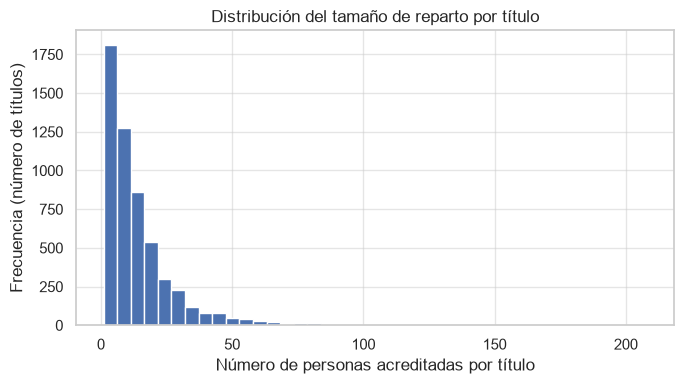

In [19]:
# Gráfica 1: Histograma de tamano_reparto (escala log en eje x por el sesgo detectado)
plt.figure(figsize=(7, 4))
plt.hist(tamano_reparto, bins=40, color="#4C72B0", edgecolor="white")
plt.title("Distribución del tamaño de reparto por título")
plt.xlabel("Número de personas acreditadas por título")
plt.ylabel("Frecuencia (número de títulos)")
plt.tight_layout()
plt.show()

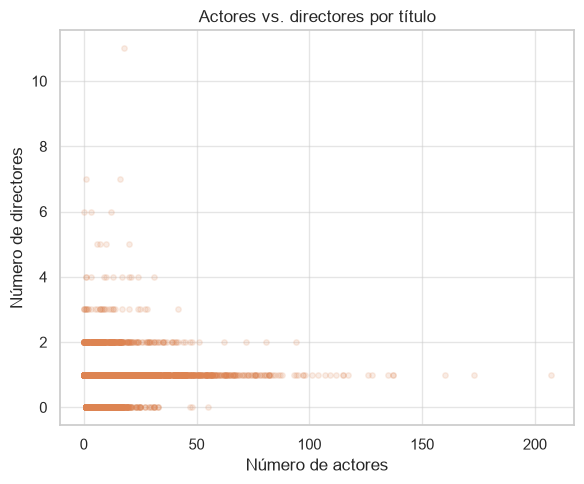

In [20]:
# Gráfica 2: Scatter entre número de actores y número de directores por título
plt.figure(figsize=(6, 5))
plt.scatter(por_titulo['actors'], por_titulo['directors'], alpha=0.15, s=15, color="#DD8452")
plt.title("Actores vs. directores por título")
plt.xlabel("Número de actores")
plt.ylabel("Número de directores")
plt.tight_layout()
plt.show()

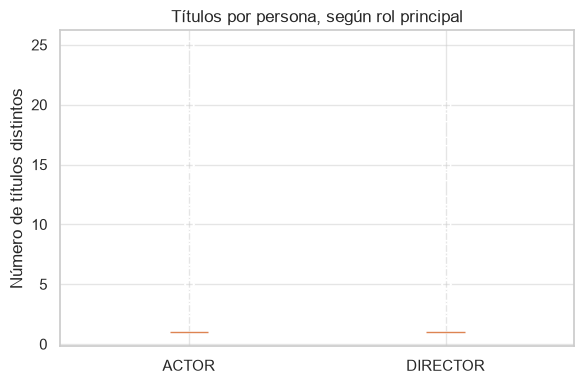

In [21]:
# Gráfica 3: Boxplot de titulos_por_persona por rol principal (categórica)
plt.figure(figsize=(6, 4))
data_box = [actores.values, directores.values]
plt.boxplot(data_box, tick_labels=["ACTOR", "DIRECTOR"], showfliers=True)
plt.title("Títulos por persona, según rol principal")
plt.ylabel("Número de títulos distintos")
plt.tight_layout()
plt.show()

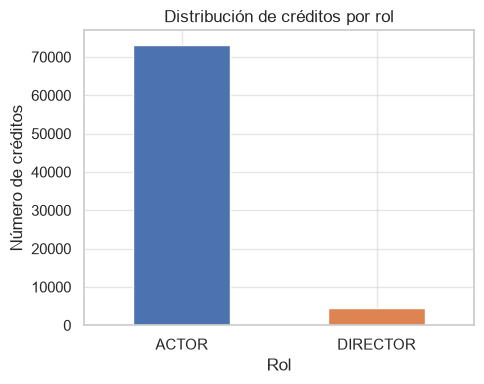

In [22]:
# Gráfica 4: Barras con la distribución de la variable categórica role
plt.figure(figsize=(5, 4))
df['role'].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Distribución de créditos por rol")
plt.xlabel("Rol")
plt.ylabel("Número de créditos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Visualización con Seaborn (mínimo 3 gráficas)

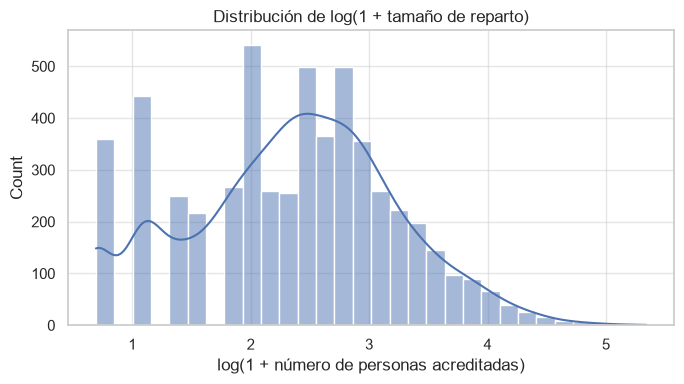

In [23]:
# Gráfica 1: histplot de tamano_reparto con transformación log para leer mejor la cola larga
plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(tamano_reparto), bins=30, kde=True, color="#4C72B0")
plt.title("Distribución de log(1 + tamaño de reparto)")
plt.xlabel("log(1 + número de personas acreditadas)")
plt.tight_layout()
plt.show()

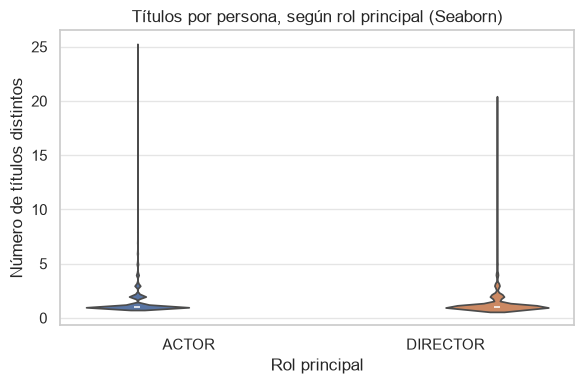

In [24]:
# Gráfica 2: boxplot/violinplot de titulos_por_persona por rol_principal
plt.figure(figsize=(6, 4))
sns.violinplot(x=personas['rol_principal'], y=personas['titulos_por_persona'], hue=personas['rol_principal'], legend=False)
plt.title("Títulos por persona, según rol principal (Seaborn)")
plt.xlabel("Rol principal")
plt.ylabel("Número de títulos distintos")
plt.tight_layout()
plt.show()

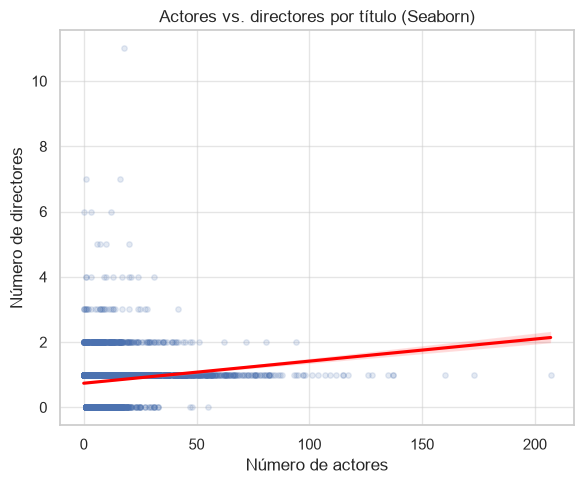

In [25]:
# Gráfica 3: scatterplot actores vs directores por título con línea de tendencia
plt.figure(figsize=(6, 5))
sns.regplot(x='actors', y='directors', data=por_titulo, scatter_kws={"alpha": 0.15, "s": 15}, line_kws={"color": "red"})
plt.title("Actores vs. directores por título (Seaborn)")
plt.xlabel("Número de actores")
plt.ylabel("Número de directores")
plt.tight_layout()
plt.show()

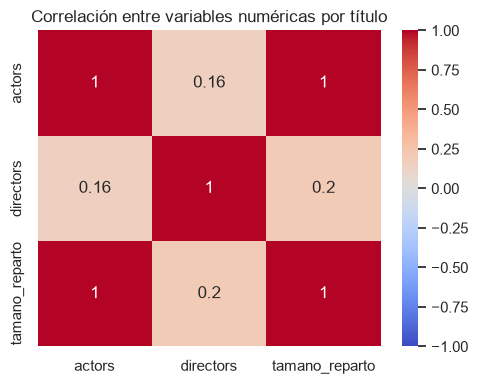

In [26]:
# Gráfica 4: heatmap de correlación entre variables numéricas por título
plt.figure(figsize=(5, 4))
corr = por_titulo[['actors', 'directors', 'tamano_reparto']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas por título")
plt.tight_layout()
plt.show()

**Comparación Matplotlib vs. Seaborn:** para el histograma y el *scatterplot*, Matplotlib exige definir manualmente cada elemento (bins, colores, título), mientras que Seaborn ofrece por defecto una estética más cuidada y funciones de alto nivel como `regplot` (línea de tendencia automática) o `histplot(..., kde=True)` (curva de densidad superpuesta) que en Matplotlib requerirían varias líneas adicionales. El `heatmap` de Seaborn, en particular, no tiene un equivalente directo tan simple en Matplotlib puro (habría que combinar `imshow` con anotaciones manuales de texto).

## 6. Preguntas de pensamiento crítico

**¿Cuándo conviene usar Matplotlib y cuándo Seaborn?**
Matplotlib conviene cuando se necesita control total sobre cada elemento de la gráfica (por ejemplo, el gráfico de barras de la sección 4, donde se definieron colores y ticks a la medida) o para gráficas simples y rápidas. Seaborn conviene cuando se trabaja directamente con un DataFrame y se quieren gráficas estadísticas ya elaboradas, como el `heatmap` de correlación o el `regplot` con línea de tendencia de la sección 5, que en Matplotlib tomarían mucho más código.

**¿Qué ventajas aporta NumPy frente a trabajar solo con Pandas?**
NumPy permite operaciones vectorizadas de bajo nivel (como la estandarización z-score de la sección 2) sin escribir ciclos `for`, con mejor rendimiento sobre arreglos grandes, y ofrece funciones numéricas (percentiles, `unique` con conteos) que Pandas internamente reutiliza. Además, muchas librerías de IA (scikit-learn, TensorFlow, PyTorch) reciben arreglos de NumPy como entrada estándar.

**¿Qué aportó SciPy que no era tan directo con NumPy/Pandas?**
SciPy aportó pruebas estadísticas formales con su propio p-valor (Shapiro-Wilk para normalidad, prueba t de Welch) que NumPy no calcula directamente, y funciones específicas como `zscore` y `spearmanr` que hubiera sido necesario programar manualmente con NumPy/Pandas.

**Si el objetivo fuera construir un modelo de IA (predicción), ¿qué herramienta sumarían y por qué?**
Se sumaría **scikit-learn**, ya que provee de forma directa algoritmos de clasificación/regresión, herramientas de partición de datos (`train_test_split`) y de evaluación de modelos, construidas justamente sobre arreglos de NumPy y DataFrames de Pandas ya preparados en este taller.

**¿Qué limitaciones detectaron en su *dataset* para aplicar análisis estadístico o visual?**
El archivo `credits.csv` no trae variables numéricas de medida originales (solo identificadores), por lo que fue necesario construir variables derivadas (`tamano_reparto`, `titulos_por_persona`) mediante agregación. Tampoco incluye información temporal, de género/categoría del título ni de calificación, lo que limita el análisis a la composición del reparto y no permite relacionar, por ejemplo, el tamaño del reparto con el año de lanzamiento o el tipo de contenido sin cruzar este archivo con `titles.csv` del mismo *dataset* de Kaggle.